# DBSCAN Clustering from Scratch

## Objectives

- Understand Density-Based Spatial Clustering of Applications with Noise.
- Implement DBSCAN using NumPy.
- Identify core, border, and noise points.
- Understand the effect of `eps` and `min_samples`.
- Compare the implementation with Scikit-Learn.

## DBSCAN Intuition

DBSCAN groups points based on density rather than requiring a predefined
number of clusters.

Main concepts:

- `eps`: Maximum distance used to define a neighborhood.
- `min_samples`: Minimum number of points required to form a dense region.
- Core point: Has at least `min_samples` points in its neighborhood.
- Border point: Is close to a core point but does not have enough neighbors.
- Noise point: Does not belong to any cluster.

DBSCAN can discover irregularly shaped clusters and identify noise points.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

In [3]:
X, _ = make_moons(
    n_samples=400,
    noise=0.08,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df.head()

,Feature_1,Feature_2
0,-0.033226,0.420541
1,0.693183,-0.411493
2,0.836026,0.532761
3,0.145537,0.283647
4,0.093859,0.955842


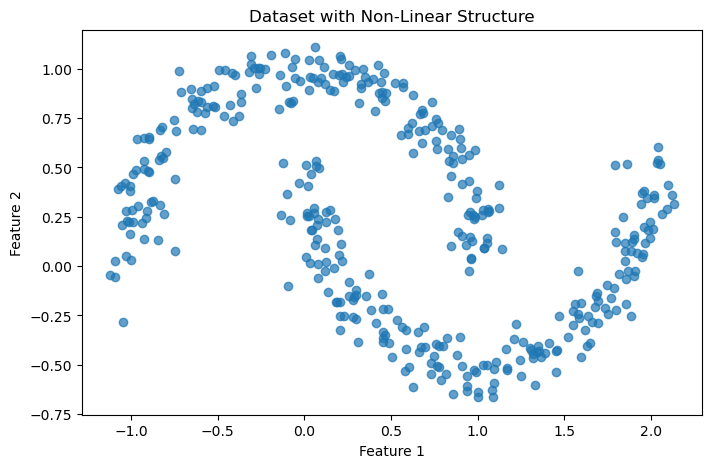

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset with Non-Linear Structure")

plt.show()

In [5]:
class DBSCANScratch:

    def __init__(self, eps=0.2, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None

    def _get_neighbors(self, X, point_index):
        distances = np.sqrt(
            np.sum(
                (X - X[point_index]) ** 2,
                axis=1
            )
        )

        return np.where(distances <= self.eps)[0]

    def fit(self, X):
        X = np.asarray(X)

        n_samples = len(X)

        labels = np.full(
            n_samples,
            -1,
            dtype=int
        )

        visited = np.zeros(
            n_samples,
            dtype=bool
        )

        cluster_id = 0

        for point in range(n_samples):

            if visited[point]:
                continue

            visited[point] = True

            neighbors = self._get_neighbors(
                X,
                point
            )

            if len(neighbors) < self.min_samples:
                labels[point] = -1
                continue

            labels[point] = cluster_id

            seeds = list(neighbors)

            i = 0

            while i < len(seeds):

                current = seeds[i]

                if not visited[current]:

                    visited[current] = True

                    current_neighbors = self._get_neighbors(
                        X,
                        current
                    )

                    if len(current_neighbors) >= self.min_samples:

                        for neighbor in current_neighbors:

                            if neighbor not in seeds:
                                seeds.append(neighbor)

                if labels[current] == -1:
                    labels[current] = cluster_id

                i += 1

            cluster_id += 1

        self.labels_ = labels

        return self

    def predict(self, X):
        return self.labels_

In [6]:
dbscan = DBSCANScratch(
    eps=0.2,
    min_samples=5
)

dbscan.fit(X)

labels = dbscan.labels_

print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", np.sum(labels == -1))

Number of clusters: 2
Noise points: 1


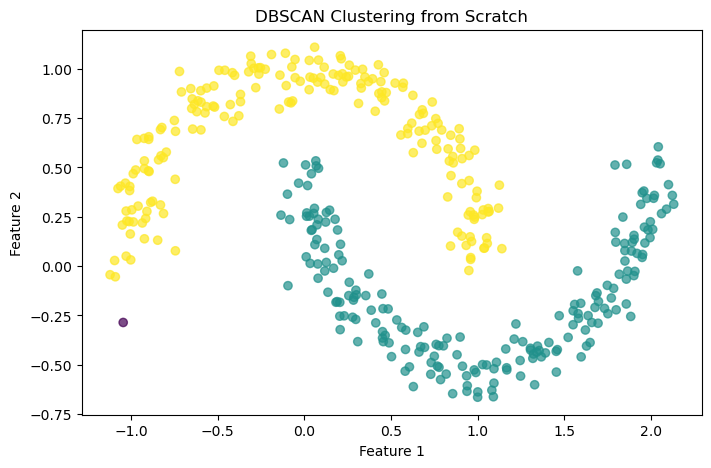

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering from Scratch")

plt.show()

In [8]:
eps_values = [0.10, 0.15, 0.20, 0.25, 0.30]

for eps in eps_values:

    model = DBSCANScratch(
        eps=eps,
        min_samples=5
    )

    model.fit(X)

    labels = model.labels_

    n_clusters = len(
        set(labels) - {-1}
    )

    n_noise = np.sum(
        labels == -1
    )

    print(
        f"eps={eps:.2f} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise}"
    )

eps=0.10 | clusters=11 | noise=25
eps=0.15 | clusters=2 | noise=5
eps=0.20 | clusters=2 | noise=1
eps=0.25 | clusters=2 | noise=0
eps=0.30 | clusters=1 | noise=0


## Clustering Evaluation

The Silhouette Score can be used when DBSCAN produces at least two
clusters and not all points are classified as noise.

Noise points are excluded from the calculation below.

In [9]:
cluster_mask = labels != -1

if (
    len(set(labels[cluster_mask])) >= 2
    and np.sum(cluster_mask) > 1
):
    score = silhouette_score(
        X[cluster_mask],
        labels[cluster_mask]
    )

    print("Silhouette Score:", score)

else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score cannot be calculated.


In [10]:
sklearn_dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

sklearn_labels = sklearn_dbscan.fit_predict(X)

scratch_clusters = len(
    set(dbscan.labels_) - {-1}
)

sklearn_clusters = len(
    set(sklearn_labels) - {-1}
)

comparison = pd.DataFrame({
    "Implementation": [
        "From Scratch",
        "Scikit-Learn"
    ],
    "Clusters": [
        scratch_clusters,
        sklearn_clusters
    ],
    "Noise Points": [
        np.sum(dbscan.labels_ == -1),
        np.sum(sklearn_labels == -1)
    ]
})

comparison

,Implementation,Clusters,Noise Points
0,From Scratch,2,1
1,Scikit-Learn,2,1


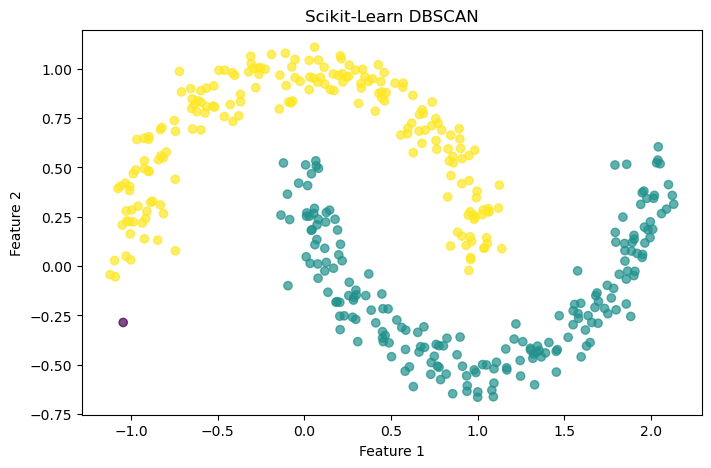

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=sklearn_labels,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scikit-Learn DBSCAN")

plt.show()

## Conclusion

- DBSCAN is a density-based clustering algorithm.
- It does not require the number of clusters to be specified beforehand.
- `eps` and `min_samples` strongly influence the clustering result.
- DBSCAN can identify noise and outliers.
- It can discover non-linear and irregularly shaped clusters.
- The algorithm can perform poorly when cluster densities vary significantly.

## Limitations

- Selecting suitable `eps` and `min_samples` can be difficult.
- DBSCAN can struggle with clusters having very different densities.
- Performance can decrease as the number of samples increases.